<img src="https://upload.wikimedia.org/wikipedia/commons/3/35/Uba_fiuba_ingenieria_logo.png" width="300" align="center">



# **Analisis de Series de Tiempo II**

# **Clase 3, LSTM, GRU y Benchmark contra el Naive (Caso APPLE)**

Comparar tres tipos de redes recurrentes (RNN simple, GRU y LSTM) para predecir el siguiente retorno diario de una acción (AAPL), y ver si superan a un baseline naive.

Importamos las librerias necesarias

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset

Fijamos las semillas para reproducibilidad

In [ ]:
np.random.seed(42)
torch.manual_seed(42)

Descargamos y preparamos la serie de precios de una acción (AAPL)

In [ ]:
URL = "https://raw.githubusercontent.com/plotly/datasets/master/finance-charts-apple.csv"
df = pd.read_csv(URL, parse_dates=["Date"]).sort_values("Date")
precios = df["AAPL.Close"].values.astype(np.float32)

Graficamos la serie de precios de cierre

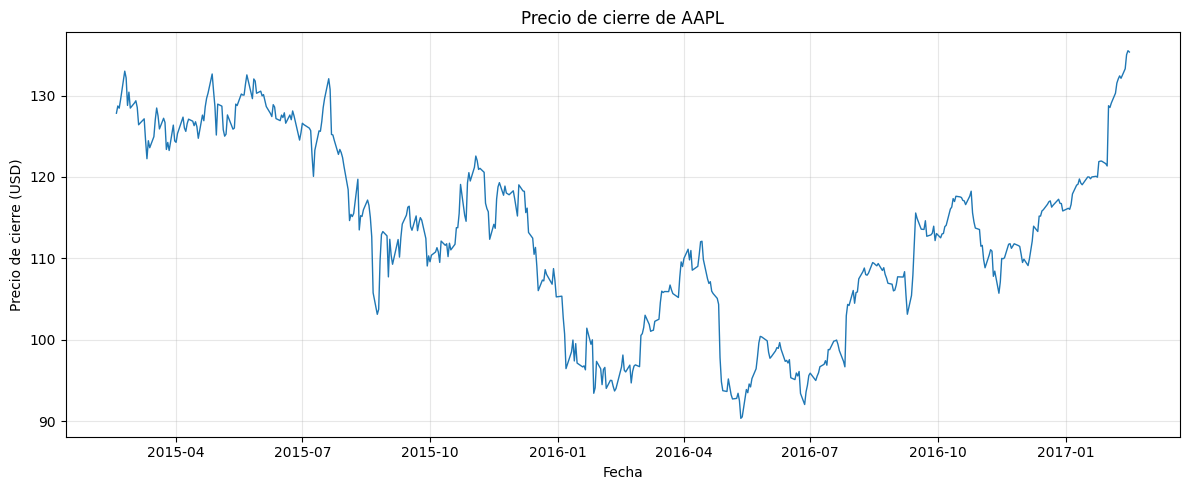

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(df["Date"], precios, linewidth=1)
plt.title("Precio de cierre de AAPL")
plt.xlabel("Fecha")
plt.ylabel("Precio de cierre (USD)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Convertimos a retornos diarios (log-retornos), que es la serie estacionaria que modelamos

In [ ]:
retornos = np.diff(np.log(precios)).astype(np.float32)
retornos = retornos / np.abs(retornos).max() # normalizamos a [-1, 1]
serie = retornos

Construimos las ventanas de train y test con split temporal. Usa ventana de 20 días hábiles

In [ ]:
L, H = 20, 1  # ventana de 20 días hábiles
n_tr = int(len(serie) * 0.8)
X_tr, y_tr, X_te, y_te = [], [], [], []

for i in range(0, n_tr - L - H + 1, 1):
    X_tr.append(serie[i : i + L])
    y_tr.append(serie[i + L : i + L + H])

for i in range(n_tr - L, len(serie) - L - H + 1, 1):
    X_te.append(serie[i : i + L])
    y_te.append(serie[i + L : i + L + H])

X_tr = torch.tensor(np.array(X_tr)).unsqueeze(-1)
y_tr = torch.tensor(np.array(y_tr))
X_te = torch.tensor(np.array(X_te)).unsqueeze(-1)
y_te = torch.tensor(np.array(y_te))

Contamos los parámetros de cada celda: el precio de las compuertas. Crea la celda con d_h=64

In [ ]:
for nombre, tipo in [("RNN", nn.RNN), ("GRU", nn.GRU), ("LSTM", nn.LSTM)]:
    celda = tipo(1, 64, batch_first=True)                       # creamos la celda con d_h=64
    total = sum(p.numel() for p in celda.parameters())          # sumamos todos sus parámetros
    print(f"{nombre:5s} (d_h=64): {total:>6,d} parámetros")

RNN   (d_h=64):  4,288 parámetros
GRU   (d_h=64): 12,864 parámetros
LSTM  (d_h=64): 17,152 parámetros


Calculamos el baseline naive: el siguiente retorno = el retorno actual

In [ ]:
naive = ((X_te[:, -1, 0:1] - y_te)**2).mean().sqrt().item()
print(f"\n{'modelo':8s} RMSE next-return")
print(f"{'naive':8s} {naive:.4f}")


modelo   RMSE next-return
naive    0.2228


Entrenamos las tres celdas con el mismo ciclo: solo cambia la celda

* Entrena 5 epochs
* MSE como Loss Function
* Aplica Gradient Clipping con threshold igual a 1

Utiliza RMSE

In [ ]:
for nombre, tipo in [("RNN", nn.RNN), ("GRU", nn.GRU), ("LSTM", nn.LSTM)]:
    torch.manual_seed(42)  # misma semilla para comparar justo
    rnn = tipo(1, 64, batch_first=True)  # creamos la celda recurrente
    cabeza = nn.Linear(64, 1) # definimos la cabeza de salida
    parametros = list(rnn.parameters()) + list(cabeza.parameters())
    optimizador = torch.optim.Adam(parametros, lr=3e-3) # definimos el optimizador
    lotes = DataLoader(TensorDataset(X_tr, y_tr), batch_size=256, shuffle=True)

    for epoca in range(5):  # entrenamos 5 épocas
        for xb, yb in lotes: # recorremos los minibatches
            optimizador.zero_grad() # limpiamos los gradientes
            salida, _ = rnn(xb) # la celda recorre las ventanas
            prediccion = cabeza(salida[:, -1])  # predecimos desde el último estado
            perdida = ((prediccion - yb)**2).mean() # calculamos el MSE
            perdida.backward()  # propagamos el gradiente
            nn.utils.clip_grad_norm_(parametros, 1.0) # aplicamos gradient clipping (siempre)
            optimizador.step() # actualizamos los pesos

    with torch.no_grad():  # evaluamos sin gradientes
        salida, _ = rnn(X_te)
        rmse = ((cabeza(salida[:, -1]) - y_te)**2).mean().sqrt().item()
    print(f"{nombre:8s} {rmse:.4f}")

RNN      0.1655
GRU      0.1590
LSTM     0.1550


Es esperable que el RMSE de naive sea aproximadamente 0.2 y de los RNNs menor a 0.17